# Random forests

**UWE Bristol · Introduction to Machine Learning**

This notebook walks through one classification model from start to finish: **Random forest**.

You will see:

1. how the model works, in plain language;
2. how to load, explore and prepare a dataset (pre-processing);
3. why we split the data into a training set and a test set;
4. how to train (fit) the model and make predictions;
5. how to measure performance with accuracy, a confusion matrix, precision, recall, F1 and a ROC curve;
6. how to visualise what the model has learned;
7. what happens when you change the model's settings.

No previous experience with the model is assumed. Run each cell in order with **Shift + Enter**, and
read the text above each cell before you run it.

## 1. How Random forest works

### The idea

A single decision tree is easy to understand, but it tends to overfit, and small changes in the data
can give a completely different tree. A random forest fixes this by building **many** trees and letting
them **vote**.

This is sometimes called the **wisdom of crowds**. If you ask one person to guess the number of sweets
in a jar, they may be well off. If you ask 100 people and take the average, individual errors tend to
cancel out and the answer is usually much closer. This only works if the people make **different**
mistakes, so a random forest deliberately makes its trees different from each other.

### Two sources of randomness

1. **Bootstrap samples (bagging).** Each tree is trained on a random sample of the training data, drawn
   *with replacement*. Some tumours appear several times in a tree's sample and others not at all. On
   average, each tree sees about two-thirds of the different training tumours.
2. **Random features.** At every question, each tree may only choose from a random subset of the
   features, not all 30. This stops every tree from asking the same first question.

### Making a prediction

To classify a new tumour, every tree gives its answer, and the forest goes with the majority. The share
of trees voting malignant acts as the forest's probability.

### A free check: the out-of-bag score

Because each tree never saw about a third of the training tumours, those tumours can be used to check
that tree. Combining these checks gives the **out-of-bag (OOB) score**: an estimate of accuracy on new
data that comes for free, without using the test set.

## Setting up

First we import the libraries we need. Each line has a comment saying what it is for.

In [1]:
# pandas holds data in tables (DataFrames); numpy does the number crunching
import pandas as pd
import numpy as np
# matplotlib draws our charts
import matplotlib.pyplot as plt

# The dataset, and tools for splitting and scaling it
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Performance measures and chart helpers
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, roc_auc_score)
from sklearn.inspection import DecisionBoundaryDisplay

# The model for this notebook
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Chart settings and colours used throughout
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BENIGN_COLOUR = "#2a78d6"      # blue
MALIGNANT_COLOUR = "#eb6834"   # orange
TRAIN_COLOUR = "#1D1C21"       # dark grey
CHECK_COLOUR = "#2a78d6"       # blue

## 2. The dataset

We use the **Breast Cancer Wisconsin** dataset, which comes built into scikit-learn, so there is
nothing to download. Each row is one breast tumour. The columns are measurements taken from a
microscope image of cells from the tumour, such as the radius of the cell nuclei, their texture
(how varied the grey levels are) and how many concave points (inward dents) their outlines have.

Our job is to predict whether each tumour is **malignant** (cancerous) or **benign** (not cancerous).
There are only two possible answers, so this is a **binary classification** problem.

In [2]:
# Load the data as a pandas DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Number of tumours (rows):", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of tumours (rows): 569
Number of columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


There are 569 tumours and 31 columns: 30 measurements, which are the **features** (the inputs), and
a column called `target`, which is the **label** (the answer we want to predict).

The 30 features are really 10 measurements, each recorded in three ways: the `mean` across the cells
in the image, the `error` (how much the values varied) and the `worst` (the average of the three
largest values).

## 3. Exploring the data

Before building any model it is worth looking at the data. We want to know how many examples there
are of each class and whether the features look useful.

### Fixing the label

In this dataset `target` is **0 for malignant and 1 for benign**, which is the opposite of what most
people would expect. scikit-learn treats the class labelled 1 as the "positive" class when it calculates
precision and recall, and we care most about finding malignant tumours. So we make a new, clearer
label column where **1 means malignant** and **0 means benign**.

malignant
benign (0)       357
malignant (1)    212
Name: count, dtype: int64


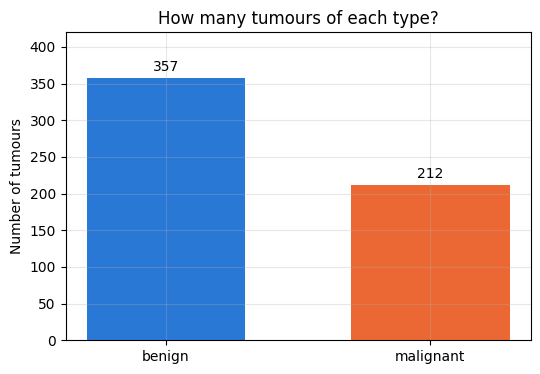

In [3]:
# New label: 1 = malignant, 0 = benign
df["malignant"] = (df["target"] == 0).astype(int)
df = df.drop(columns="target")

counts = df["malignant"].value_counts().sort_index()
print(counts.rename({0: "benign (0)", 1: "malignant (1)"}))

plt.figure(figsize=(6, 4))
bars = plt.bar(["benign", "malignant"], counts.values, color=[BENIGN_COLOUR, MALIGNANT_COLOUR], width=0.6)
plt.bar_label(bars, padding=3)
plt.ylabel("Number of tumours")
plt.title("How many tumours of each type?")
plt.ylim(0, 420)
plt.show()

There are 357 benign and 212 malignant tumours, so about 63% are benign. The classes are not
perfectly balanced. This gives us a useful **baseline**: a lazy "model" that always says benign would
be right about 63% of the time. Any real model has to do a lot better than that to be worth using.

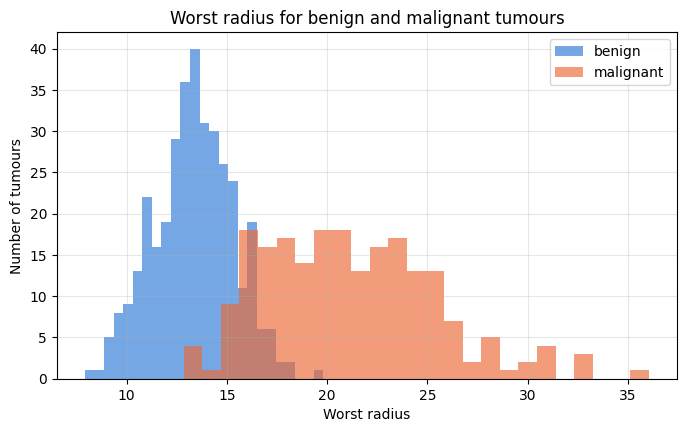

In [4]:
# Does one feature on its own separate the two classes?
plt.figure(figsize=(8, 4.5))
plt.hist(df.loc[df["malignant"] == 0, "worst radius"], bins=25, alpha=0.65,
         color=BENIGN_COLOUR, label="benign")
plt.hist(df.loc[df["malignant"] == 1, "worst radius"], bins=25, alpha=0.65,
         color=MALIGNANT_COLOUR, label="malignant")
plt.xlabel("Worst radius")
plt.ylabel("Number of tumours")
plt.title("Worst radius for benign and malignant tumours")
plt.legend()
plt.show()

Malignant tumours tend to have larger cells, but the two groups overlap in the middle. No single
measurement separates them perfectly, which is why we want a model that combines all 30.

## 4. Data pre-processing

Pre-processing means checking and preparing the data so that a model can learn from it properly.

### 4.1 Missing values and duplicates

In [5]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


This dataset has no missing values and no duplicated rows, which is unusual. With real-world data you
would normally need to deal with gaps, for example by removing incomplete rows or filling each gap
with the column's median value.

### 4.2 Separating the features (X) and the label (y)

By convention we call the inputs `X` and the answers `y`.

In [6]:
X = df.drop(columns="malignant")   # the 30 measurements
y = df["malignant"]                 # the answer: 1 = malignant, 0 = benign

print("X:", X.shape, "   y:", y.shape)

X: (569, 30)    y: (569,)


### 4.3 Do the features need scaling?

The features are measured on very different scales:

In [7]:
X[["mean radius", "mean area", "mean smoothness"]].describe().loc[["mean", "min", "max"]].round(3)

,mean radius,mean area,mean smoothness
mean,14.127,654.889,0.096
min,6.981,143.500,0.053
max,28.110,2501.000,0.163


`mean area` is in the hundreds, while `mean smoothness` is around 0.1. For many models that would be a
problem, but not for this one. A random forest is made of decision trees, and every question in a tree compares one feature with a threshold. Rescaling a feature just moves the threshold; it does not change which tumours go which way.

So we will **not** scale the data in this notebook. (Scaling would do no harm, but it would not help
either.)

## 5. The train/test split

If we trained a model on every tumour and then tested it on the same tumours, it could score well just
by remembering them. That would tell us nothing about how it will perform on **new** patients.

So we split the data into two parts:

- the **training set**, which the model learns from, and
- the **test set**, which we hide away and only use at the end to check how well the model works on
  tumours it has never seen.

The settings we use:

- `test_size=0.25`: keep 25% of the tumours for testing.
- `stratify=y`: keep the same proportion of malignant tumours in both parts.
- `random_state=42`: the split is random, but fixing this number means you get the same split every
  time you run the notebook (and the same as everyone else in the class).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Training set:", len(X_train), "tumours")
print("Test set:    ", len(X_test), "tumours")
print("Malignant in training set:", round(y_train.mean() * 100, 1), "%")
print("Malignant in test set:    ", round(y_test.mean() * 100, 1), "%")

Training set: 426 tumours
Test set:     143 tumours
Malignant in training set: 37.3 %
Malignant in test set:     37.1 %


Thanks to `stratify=y`, both sets contain the same share of malignant tumours (about 37%).

This model does not need scaling, so we can use the training and test sets exactly as they are.
To keep the code the same shape as the other notebooks, we just give them new names.

In [9]:
X_train_ready = X_train
X_test_ready = X_test

## 6. Fitting (training) the model


We create a forest of 100 trees and fit it. Setting `oob_score=True` asks the forest to calculate the
out-of-bag score as it trains. `random_state` makes the random choices repeatable.

In [10]:
model = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=0)
model.fit(X_train_ready, y_train)

print("Number of trees in the forest:", len(model.estimators_))
print(f"Training accuracy:       {model.score(X_train_ready, y_train):.3f}")
print(f"Out-of-bag (OOB) score:  {model.oob_score_:.3f}")

Number of trees in the forest: 100
Training accuracy:       1.000
Out-of-bag (OOB) score:  0.958


The training accuracy is 100%: between them, the trees have learned every training tumour. The
out-of-bag score is a much more honest estimate of how the forest will do on new tumours, and we can
compare it with the test accuracy in section 8.

## 7. Making predictions

With the model trained, we ask it to predict the label for every tumour in the **test set**. These are
tumours it has never seen.

As well as a yes/no answer, `predict_proba` gives the model's estimated **probability** that each
tumour is malignant. By default, the model predicts malignant when that probability is 0.5 or more.

In [11]:
y_pred = model.predict(X_test_ready)
y_prob = model.predict_proba(X_test_ready)[:, 1]   # probability of malignant

# Compare the first 10 predictions with the real answers
first_ten = pd.DataFrame({
    "actual": y_test.values[:10],
    "predicted": y_pred[:10],
    "probability of malignant": y_prob[:10].round(3),
})
first_ten["correct?"] = np.where(first_ten["actual"] == first_ten["predicted"], "yes", "NO")
first_ten

,actual,predicted,probability of malignant,correct?
0,1,1,0.95,yes
1,0,0,0.02,yes
2,1,1,0.92,yes
3,0,0,0.00,yes
4,0,0,0.38,yes
5,0,0,0.00,yes
6,0,0,0.03,yes
7,0,0,0.00,yes
8,0,0,0.03,yes
9,0,0,0.24,yes


## 8. Measuring performance

There are several ways to measure how good a classifier is. Each one answers a slightly different
question, and for a medical problem like this the differences really matter.

### 8.1 Accuracy

Accuracy is the simplest measure: **what fraction of predictions were correct?**

In [12]:
accuracy = accuracy_score(y_test, y_pred)
baseline = (y_test == 0).mean()   # always guessing "benign"

print(f"Accuracy of the model:          {accuracy:.3f}")
print(f"Accuracy of always saying benign: {baseline:.3f}")

Accuracy of the model:          0.972
Accuracy of always saying benign: 0.629


The model is well above the baseline. But accuracy on its own hides an important detail: **what kind
of mistakes** did the model make?

### 8.2 The confusion matrix

A confusion matrix sorts every prediction into one of four boxes:

| | Model says benign | Model says malignant |
|---|---|---|
| **Really benign** | True negative (TN): correct | False positive (FP): a false alarm |
| **Really malignant** | False negative (FN): a missed cancer | True positive (TP): correct |

The two kinds of mistake are not equally bad. A false alarm means a worried patient and an extra test.
A false negative means a cancer is missed.

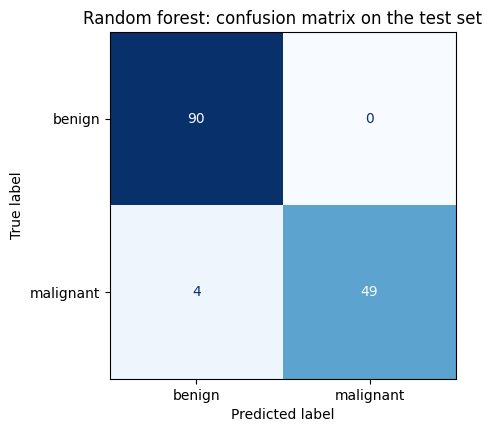

True negatives  (benign, correctly identified):    90
False positives (benign, wrongly called malignant): 0
False negatives (malignant, missed):               4
True positives  (malignant, correctly found):      49


In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["benign", "malignant"], cmap="Blues", colorbar=False
)
plt.title("Random forest: confusion matrix on the test set")
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True negatives  (benign, correctly identified):    {tn}")
print(f"False positives (benign, wrongly called malignant): {fp}")
print(f"False negatives (malignant, missed):               {fn}")
print(f"True positives  (malignant, correctly found):      {tp}")

### 8.3 Precision, recall and F1

These three measures focus on the malignant class:

- **Precision** = TP / (TP + FP). Of all the tumours the model *called* malignant, what fraction really
  were? High precision means few false alarms.
- **Recall** = TP / (TP + FN). Of all the tumours that *really were* malignant, what fraction did the
  model find? High recall means few missed cancers. (Recall is also called **sensitivity**.)
- **F1 score** combines precision and recall into one number. It is only high when both are high.

For cancer screening, recall is usually the most important of these, because missing a cancer is the
worst outcome.

In [14]:
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")

Precision: 1.000
Recall:    0.925
F1 score:  0.961


`classification_report` prints all of these at once, for **both** classes. The `support` column is the
number of test tumours in each class.

In [15]:
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

              precision    recall  f1-score   support

      benign       0.96      1.00      0.98        90
   malignant       1.00      0.92      0.96        53

    accuracy                           0.97       143
   macro avg       0.98      0.96      0.97       143
weighted avg       0.97      0.97      0.97       143



### 8.4 The ROC curve and AUC

The model's decision depends on the 0.5 probability threshold. If we lowered the threshold, it would
catch more malignant tumours but raise more false alarms; if we raised it, the opposite.

A **ROC curve** shows this trade-off across every possible threshold. It plots the **true positive
rate** (recall) against the **false positive rate** (the fraction of benign tumours wrongly flagged).
A perfect model goes straight up the left side and along the top. A model that guesses at random
follows the dashed diagonal line.

The **AUC** (area under the curve) sums this up in one number, from 0.5 (guessing) to 1.0 (perfect).

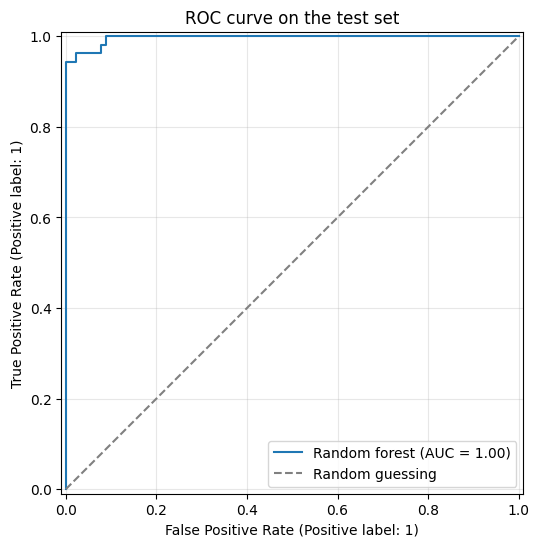

AUC: 0.996


In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, name="Random forest", ax=ax)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guessing")
ax.set_title("ROC curve on the test set")
ax.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")

## 9. Looking inside the model

### Watching the trees vote

Let's ask every one of the 100 trees for its answer on the first 8 test tumours, and count the votes.

In [17]:
first_eight = X_test_ready.iloc[:8]
votes = np.array([tree.predict(first_eight.values) for tree in model.estimators_])
malignant_votes = votes.sum(axis=0)

vote_table = pd.DataFrame({
    "trees voting malignant": malignant_votes.astype(int),
    "trees voting benign": (100 - malignant_votes).astype(int),
    "forest's prediction": np.where(malignant_votes > 50, "malignant", "benign"),
    "really": np.where(y_test.iloc[:8] == 1, "malignant", "benign"),
})
vote_table

,trees voting malignant,trees voting benign,forest's prediction,really
0,95,5,malignant,malignant
1,2,98,benign,benign
2,92,8,malignant,malignant
3,0,100,benign,benign
4,38,62,benign,benign
5,0,100,benign,benign
6,3,97,benign,benign
7,0,100,benign,benign


Many tumours get a near-unanimous vote, but for some the trees disagree. Those split votes are where
the forest is least sure.

### One tree versus the whole forest

How good is each individual tree on the test set, compared with the forest as a whole?

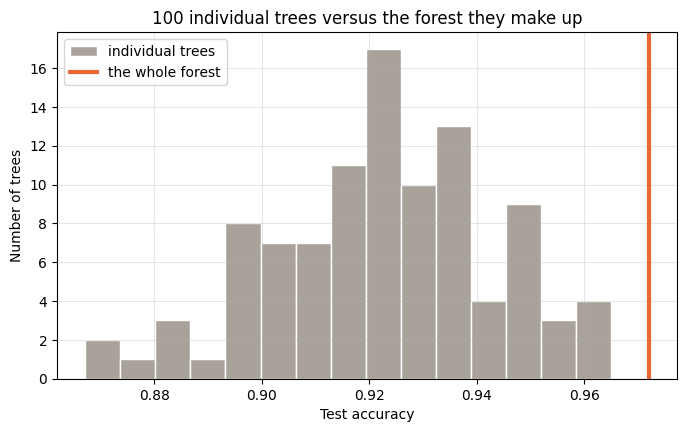

Average single tree: 0.923
Best single tree:    0.965
The forest:          0.972


In [18]:
single_tree_scores = [accuracy_score(y_test, tree.predict(X_test_ready.values)) for tree in model.estimators_]

plt.figure(figsize=(8, 4.5))
plt.hist(single_tree_scores, bins=15, color="#A8A29A", edgecolor="white", label="individual trees")
plt.axvline(accuracy_score(y_test, y_pred), color=MALIGNANT_COLOUR, lw=3, label="the whole forest")
plt.xlabel("Test accuracy")
plt.ylabel("Number of trees")
plt.title("100 individual trees versus the forest they make up")
plt.legend()
plt.show()

print(f"Average single tree: {np.mean(single_tree_scores):.3f}")
print(f"Best single tree:    {np.max(single_tree_scores):.3f}")
print(f"The forest:          {accuracy_score(y_test, y_pred):.3f}")

This is the whole point of a random forest. The forest usually beats the average tree comfortably,
and is often as good as or better than even the best single tree, because the trees' individual
mistakes cancel out when they vote.

### Which features matter most?

Feature importance in a forest is averaged over all 100 trees, which makes it more reliable than the
importance from a single tree.

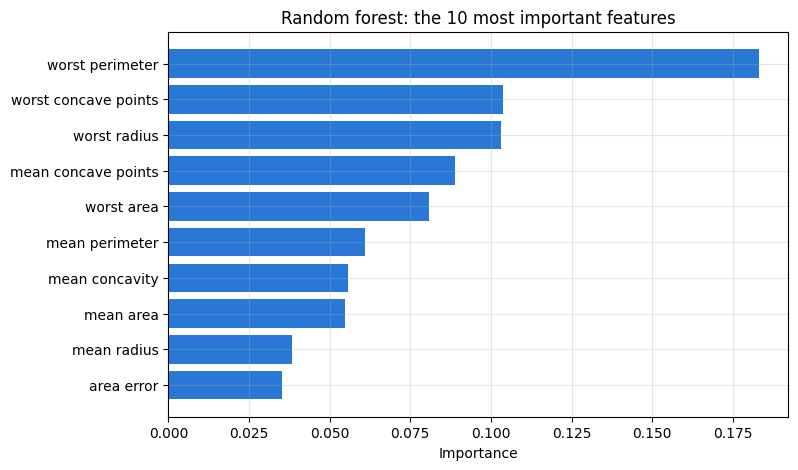

In [19]:
importance = pd.Series(model.feature_importances_, index=X.columns).sort_values().tail(10)

plt.figure(figsize=(8, 5))
plt.barh(importance.index, importance.values, color=CHECK_COLOUR)
plt.xlabel("Importance")
plt.title("Random forest: the 10 most important features")
plt.show()

Features describing the size of the cells (radius, perimeter, area) and their concave points dominate.

## 10. Seeing the decision boundary

With 30 features we cannot draw what the model has learned. But if we train the same kind of model on
just **two** features, we can plot every tumour on a flat chart and colour in the regions where the
model would predict benign or malignant. The line where the colours meet is the **decision boundary**.

We use `mean radius` and `mean texture`. These two features overlap quite a lot, which makes the
boundary more interesting to look at. This two-feature model is only for the picture; our real model
still uses all 30 features.

Compare a single, unlimited decision tree with forests of 10 and 100 trees. Each tree's boundary is made
of rectangles, but averaging many different trees smooths out the jagged edges.

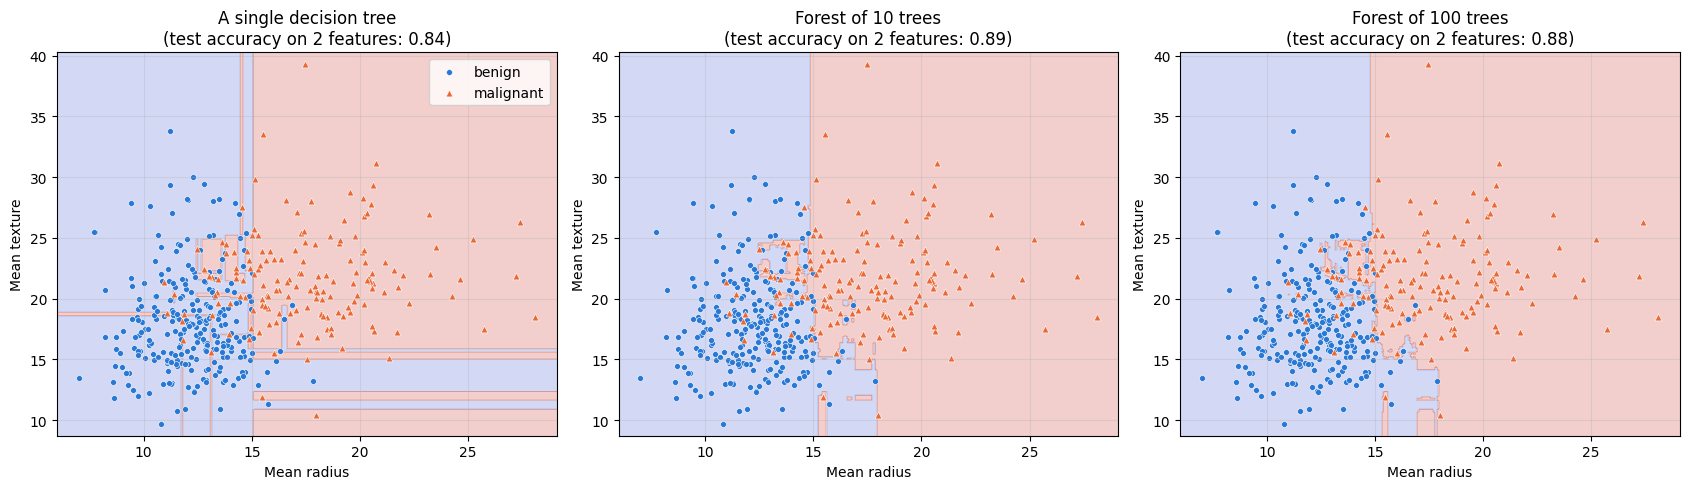

In [20]:
two = ["mean radius", "mean texture"]
X_two = X_train[two]

def draw_boundary(model, ax, title):
    """Fit a model on two features and colour in its predictions."""
    model.fit(X_two, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X_two, response_method="predict", ax=ax, alpha=0.25,
        cmap="coolwarm", grid_resolution=300, xlabel="Mean radius", ylabel="Mean texture"
    )
    benign = y_train == 0
    ax.scatter(X_two.loc[benign, two[0]], X_two.loc[benign, two[1]], s=18,
               color=BENIGN_COLOUR, edgecolor="white", linewidth=0.4, label="benign")
    ax.scatter(X_two.loc[~benign, two[0]], X_two.loc[~benign, two[1]], s=24, marker="^",
               color=MALIGNANT_COLOUR, edgecolor="white", linewidth=0.4, label="malignant")
    acc = model.score(X_test[two], y_test)
    ax.set_title(f"{title}\n(test accuracy on 2 features: {acc:.2f})")


fig, axes = plt.subplots(1, 3, figsize=(17, 5))
draw_boundary(DecisionTreeClassifier(random_state=0), axes[0], "A single decision tree")
draw_boundary(RandomForestClassifier(n_estimators=10, random_state=0), axes[1], "Forest of 10 trees")
draw_boundary(RandomForestClassifier(n_estimators=100, random_state=0), axes[2], "Forest of 100 trees")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 11. Changing the parameters

Every model has settings that we choose before training. These are called **hyperparameters**.
Changing them changes how simple or complex the model is.

### Choosing settings fairly

We must **not** use the test set to choose settings. If we tried lots of settings and kept whichever
did best on the test set, the test set would no longer be a fair check.

Instead we use **cross-validation** on the training set. The training data is split into 5 parts. The
model trains on 4 parts and is checked on the 5th, and this is repeated so that each part gets a turn.
The average of the 5 scores tells us how well a setting works on data the model did not train on.

The function below tries a list of values for one setting and plots two lines:

- **training accuracy**: how well the model does on the data it learned from;
- **cross-validated accuracy**: our fair estimate of how it will do on new data.

A big gap between the two lines is a sign of **overfitting**: the model has memorised the training data.
When both lines are low, the model is **underfitting**: it is too simple to capture the pattern.

### n_estimators: the number of trees

More trees usually help, up to a point, then the score levels off. Unlike most settings, adding more
trees does not make a forest overfit; the only cost is extra computing time.

In [21]:
def try_settings(make_model, values, setting_name, X_data, log_scale=False, tolerance=0):
    """Try each value of one setting; plot training vs cross-validated accuracy.

    The values must be listed from simplest to most complex. The chosen value is the simplest
    one whose cross-validated accuracy is within `tolerance` of the best.
    """
    train_scores, cv_scores = [], []
    for value in values:
        m = make_model(value)
        cv_scores.append(cross_val_score(m, X_data, y_train, cv=5).mean())
        train_scores.append(m.fit(X_data, y_train).score(X_data, y_train))

    plt.plot(values, train_scores, "o-", color=TRAIN_COLOUR, label="Training accuracy")
    plt.plot(values, cv_scores, "s-", color=CHECK_COLOUR, label="Cross-validated accuracy")
    if log_scale:
        plt.xscale("log")
    plt.xlabel(setting_name)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    table = pd.DataFrame({setting_name: values,
                          "training accuracy": np.round(train_scores, 3),
                          "cross-validated accuracy": np.round(cv_scores, 3)})
    top = max(cv_scores)
    best = next(v for v, s in zip(values, cv_scores) if s >= top - tolerance - 1e-9)
    return table, best

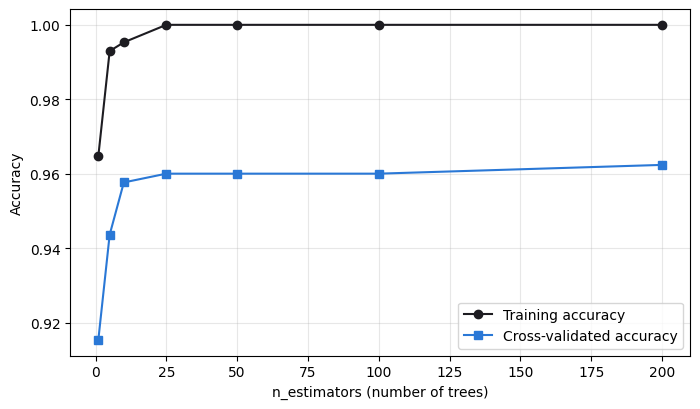

Chosen n_estimators: 200


,n_estimators (number of trees),training accuracy,cross-validated accuracy
0,1,0.965,0.915
1,5,0.993,0.944
2,10,0.995,0.958
3,25,1.000,0.960
4,50,1.000,0.960
5,100,1.000,0.960
6,200,1.000,0.962


In [22]:
tree_counts = [1, 5, 10, 25, 50, 100, 200]
table, best_trees = try_settings(lambda n: RandomForestClassifier(n_estimators=n, random_state=0),
                                 tree_counts, "n_estimators (number of trees)", X_train_ready)
print("Chosen n_estimators:", best_trees)
table

**What to notice:** a "forest" of 1 tree is just a single decision tree, and it is the weakest. Adding
trees improves the cross-validated accuracy quickly, and then the line flattens out.

### max_features: how many features each question may choose from

This controls how different the trees are from each other. With `max_features=1`, each question has to
use one randomly chosen feature. With `max_features=None`, every question can use any of the 30
features, so the trees become more alike.

In [23]:
for mf in [1, "sqrt", 0.5, None]:
    forest = RandomForestClassifier(n_estimators=100, max_features=mf, random_state=0)
    score = cross_val_score(forest, X_train_ready, y_train, cv=5).mean()
    print(f"max_features = {str(mf):>5}: cross-validated accuracy = {score:.3f}")

max_features =     1: cross-validated accuracy = 0.962


max_features =  sqrt: cross-validated accuracy = 0.960


max_features =   0.5: cross-validated accuracy = 0.965


max_features =  None: cross-validated accuracy = 0.965


The differences here are very small. The default, `"sqrt"`, lets each question choose from about 5 of the 30 features (the square root of 30); it is a sensible middle ground that works well on most datasets, so it is rarely worth changing at this level.

### Retraining with the chosen setting

Now we train a fresh model with the chosen setting on the whole training set, and check it **once** on
the test set. We compare it with the default model from earlier.

In [24]:
tuned = RandomForestClassifier(n_estimators=best_trees, random_state=0)
tuned.fit(X_train_ready, y_train)
tuned_pred = tuned.predict(X_test_ready)

summary = pd.DataFrame({
    "default model": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                      recall_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "tuned model":   [accuracy_score(y_test, tuned_pred), precision_score(y_test, tuned_pred),
                      recall_score(y_test, tuned_pred), f1_score(y_test, tuned_pred)],
}, index=["accuracy", "precision", "recall", "F1"]).round(3)
summary

,default model,tuned model
accuracy,0.972,0.979
precision,1.000,1.000
recall,0.925,0.943
F1,0.961,0.971


Tuning does not always change the result. Sometimes the default settings are already a good choice, or
the chosen setting happens to make the same predictions on these 143 test tumours. Occasionally a tuned
model even does slightly worse on the test set, because cross-validation gives a fair **estimate**, not a
guarantee. What matters is that the setting was chosen without looking at the test set, so the test
score is an honest measure of how the model is likely to perform on new patients.

## 12. Discussion

### Strengths

- Usually much more accurate than a single decision tree, and one of the most reliable models for tables of data.
- Resistant to overfitting, and adding more trees does not make it worse.
- Needs no scaling and works well with the default settings.
- Gives useful feature importances and a free out-of-bag accuracy estimate.


### Limitations

- Much harder to explain than a single tree: you cannot sensibly draw 100 trees.
- Slower to train and predict than a single tree, and the model takes more memory.
- Feature importances can be misleading when features are strongly related, as many are here.


### Where it is used

- Fraud detection in banking and card payments.
- Predicting whether customers will leave a service (churn).
- Medical research, such as predicting disease risk from patient records.
- Remote sensing, such as classifying land use from satellite images.


### When should you choose it?

A random forest is an excellent default choice for tabular data (rows and columns), especially when you
want strong accuracy without much tuning. If you need to explain every decision, a single tree or
logistic regression may be better.


## 13. Summary of the process

Every supervised learning project in this module follows the same steps you have just worked through:

1. **Understand the problem and the data**: what are the features, what is the label?
2. **Explore** the data: class balance, useful features, anything odd.
3. **Pre-process**: deal with missing values, fix labels, and scale if the model needs it.
4. **Split** into training and test sets, with scaling learned from the training set only.
5. **Fit** the model to the training data.
6. **Predict** on the test set.
7. **Measure** performance with more than one metric, thinking about which mistakes matter most.
8. **Tune** the settings with cross-validation, then check the final model once on the test set.

## 14. Your turn


1. Change `n_estimators` in section 6 to 1, then 10, then 500. Record the test accuracy and the OOB score each time.
2. Compare the OOB score with the test accuracy in section 8. Are they close? Why is the OOB score useful?
3. In section 9, find a test tumour where the trees disagree the most. Was the forest's final answer correct?
4. Add `max_depth=2` to the forest in section 6. Does limiting every tree hurt the forest? Why might it matter less than for a single tree?
5. Explain in your own words why a forest of different trees can be more accurate than its best individual tree.